In [66]:
# Add project root to path
import sys
from pathlib import Path
import lovely_tensors as lt
lt.monkey_patch()

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))
print(f"Added {project_root} to Python path")

chip_root = Path("../../chip-project")
sys.path.insert(0, str(chip_root))
print(f"Added {chip_root} to Python path")

Added /Users/lfbarba/GitHub/sdate to Python path
Added ../../chip-project to Python path


In [67]:
import math
import numpy as np
import matplotlib.pyplot as plt
import torch
from pathlib import Path
from tqdm.auto import tqdm
from skimage.metrics import structural_similarity as _skimage_ssim
from ipywidgets import interact, IntSlider


from sdate.stream_hvec import HevcGray10Streamer, concat_hevc_segments
from sdate.stream_hvec.stream_gray10 import EncoderParams
from sdate.video_compression.hevc_grayscale import decode_hevc_grayscale_10bit
from inct.dataset_slices import ProjectionSliceDataset

plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['image.cmap'] = 'gray'

print("Libraries imported successfully!")

Libraries imported successfully!


In [68]:
DATA_PATH = Path('../data/ct_files/file_1_extracted')
NUM_PROJECTIONS = 50
TARGET_SIZE = (2560//2, 2160//2)

dataset = ProjectionSliceDataset(
    folder_path=DATA_PATH,
    num_projections=NUM_PROJECTIONS,
    target_size=TARGET_SIZE,
    normalize_values=True,
    verbose=True,
    cache_volume=True,
    use_attenuation=False,
)

volume = dataset.get_full_volume()  # (H, W, D)

H, W = volume.shape[:2]
N_FRAMES = volume.shape[2]
print(f"\nVolume shape: {volume.shape}")
print(f"Image size:   {H} × {W}")
print(f"Total frames: {N_FRAMES}")

✅ Found parameters in JC_62d.log: {'num_darks': 10, 'num_flats': 100, 'num_projections': 1501}
📂 Loaded folder: file_1_extracted
   Total TIFF files: 1711
   Darks: 10, Flats: 100, Projections: 1501
   Image dimensions: 2560 x 2160
   Use attenuation: False
ProjectionSliceDataset:
  Volume shape: (1080, 1280, 50)
  Slice dimension: 2
  Slices per batch: 1
  Voxels per slice (dim=2): 1,382,400
Loading 50 projections...
  Loaded 50/50
Volume shape: (1080, 1280, 50)
Total voxels: 69,120,000
Value range: [8857.5469, 46449.3125]

Volume shape: torch.Size([1080, 1280, 50])
Image size:   1080 × 1280
Total frames: 50


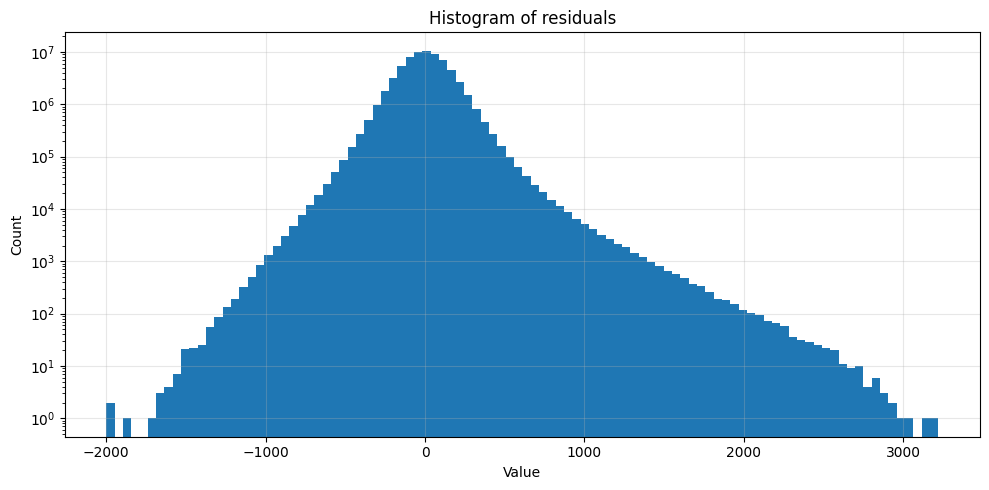

min=-1999.703125, max=3219.765625, mean=3.396090, std=155.043655


tensor[49, 1080, 1280] n=67737600 (0.3Gb) x∈[-2.000e+03, 3.220e+03] μ=3.396 σ=155.044

In [129]:
# Histogram of all values in the loaded volume
residuals = (volume[:, :, 1:] - volume[:, :, :-1])
residuals = residuals.permute(2, 0, 1)  # (D-1, H, W)

plt.figure(figsize=(10, 5))
# histogram in log metric to better visualize the distribution of values
plt.hist(residuals.ravel(), bins=100, log=True)

plt.title('Histogram of residuals')
plt.xlabel('Value')
plt.ylabel('Count')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"min={residuals.min():.6f}, max={residuals.max():.6f}, mean={residuals.mean():.6f}, std={residuals.std():.6f}")
residuals

In [130]:
from chip.utils.sinogram import compute_sinogram
import matplotlib.patches as mpatches

@interact(
    slice_idx=IntSlider(min=0, max=H-1, step=1, value=158),
    thickness=IntSlider(min=1, max=10, step=1, value=1),
    start=IntSlider(min=0, max=W-50, step=1, value=500),
)
def plot_combined(slice_idx, thickness, start):
    obj = residuals[:, slice_idx:slice_idx+thickness, :].mean(dim=1)
    patch = obj[:, start:start+N_FRAMES-1]

    # normalize patch with MAD
    norm_patch = patch - patch.median()
    norm_patch /= 1.4826 * ((patch - patch.median()).abs().median() + 1e-6)
    # patch = patch.abs()

    sinogram = compute_sinogram(patch.T, torch.linspace(10, 170, 360)).abs()

    fig = plt.figure(figsize=(15, 14))

    # Top: full residuals image with rectangle showing the patch window
    ax_res = fig.add_subplot(3, 1, 1)
    ax_res.imshow(obj, cmap='bwr', vmin=-obj.abs().max(), vmax=obj.abs().max(), aspect='auto')
    rect = mpatches.Rectangle(
        (start - 0.5, -0.5), N_FRAMES - 1, obj.shape[0],
        linewidth=2, edgecolor='black', facecolor='none'
    )
    ax_res.add_patch(rect)
    ax_res.set_title(f'Residuals (slice {slice_idx}, thickness {thickness}) — black box: patch cols {start}:{start+49}')

    # Middle-left: sinogram
    ax_sino = fig.add_subplot(3, 2, 3)
    ax_sino.imshow(sinogram, cmap='hot', aspect='auto')
    ax_sino.set_title('Sinogram')
    print("sinogram", sinogram)

    # Middle-right: patch |abs|
    ax_patch = fig.add_subplot(3, 2, 4)
    ax_patch.imshow(patch, cmap='bwr', aspect='auto', vmin=-obj.abs().max(), vmax=obj.abs().max())
    ax_patch.set_title(f'Patch |abs| (cols {start}:{start+49})')

    # Bottom: sinogram mean across angles
    ax_mean = fig.add_subplot(3, 1, 3)
    ax_mean.plot(sinogram.max(dim=0).values)
    # set ylim to 1.0
    # ax_mean.set_ylim(0, 1.0)
    ax_mean.set_title('Sinogram mean (dim=0) — mean across angles')
    ax_mean.set_xlabel('Position')
    ax_mean.set_ylabel('Mean amplitude')
    ax_mean.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


interactive(children=(IntSlider(value=158, description='slice_idx', max=1079), IntSlider(value=1, description=…

In [79]:
window_size = 10

@interact(window_size=IntSlider(min=1, max=50, step=1, value=10), frame=IntSlider(min=0, max=N_FRAMES-1, step=1, value=0), slice_idx=IntSlider(min=0, max=H-1, step=1, value=0))
def plot_residuals(window_size, frame, slice_idx):
    frame = min(frame, N_FRAMES - window_size)  # ensure frame + window_size does not exceed bounds
    plot_data = residuals[frame:frame+window_size, slice_idx, :].sum(dim=0) / residuals[frame:frame+window_size, slice_idx, :].numel()
    plt.plot(plot_data)
    plt.title(f'Sum of Residuals (frame {slice_idx})')
    plt.xlabel('Pixel Index')
    plt.ylabel('Sum of Residuals')
    # plt.ylim(min(-4e-5, -plot_data.abs().max().item()), max(4e-5, plot_data.abs().max().item()))
    plt.ylim(-0.4, 0.4)
    plt.show()

interactive(children=(IntSlider(value=10, description='window_size', max=50, min=1), IntSlider(value=0, descri…

## Metric Helpers

In [73]:
def psnr(pred: np.ndarray, tgt: np.ndarray) -> float:
    dr = float(tgt.max() - tgt.min())
    mse = float(np.mean((np.clip(pred, tgt.min(), tgt.max()) - tgt) ** 2))
    return 10 * math.log10(dr ** 2 / (mse + 1e-10))

def ssim(pred: np.ndarray, tgt: np.ndarray) -> float:
    dr = float(tgt.max() - tgt.min())
    return float(_skimage_ssim(tgt, np.clip(pred, tgt.min(), tgt.max()), data_range=dr))

print("Metric helpers ready")

Metric helpers ready


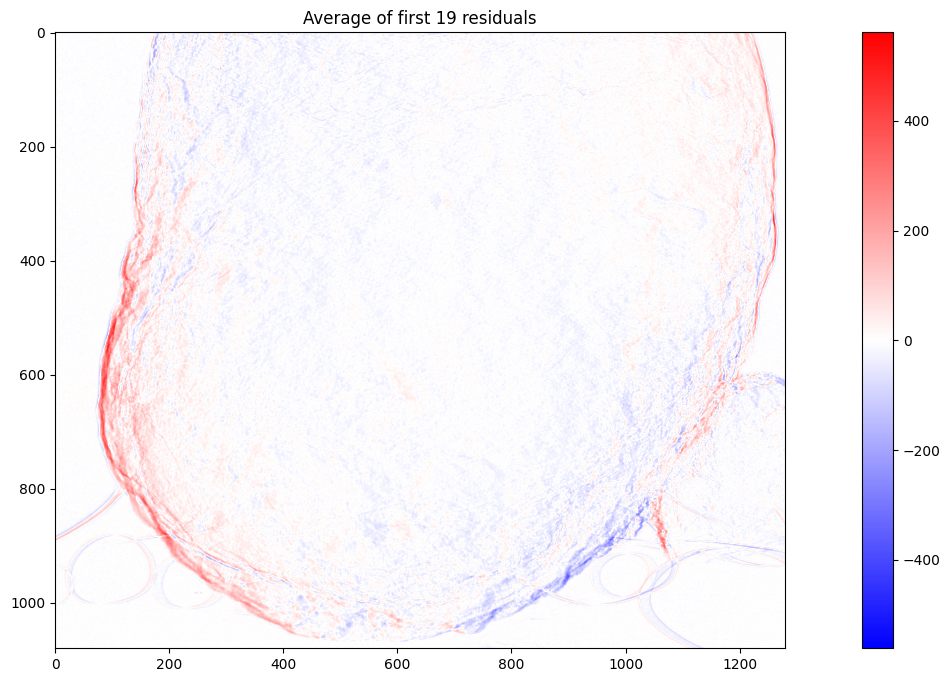

In [74]:
avg = torch.zeros_like(residuals[0])
interval = (0, 19)
for i in range(interval[0], interval[1]):
    avg += (residuals[i] - residuals[i].mean())
avg /= (interval[1] - interval[0])
plt.figure(figsize=(20, 8))
plt.imshow((avg), cmap='bwr', vmin=-avg.abs().max(), vmax=avg.abs().max())
plt.title(f"Average of first {interval[1] - interval[0]} residuals")
plt.colorbar()

tensor[1080, 1280] n=1382400 (5.3Mb) x∈[-1.000, 1.000] μ=-0.022 σ=0.226

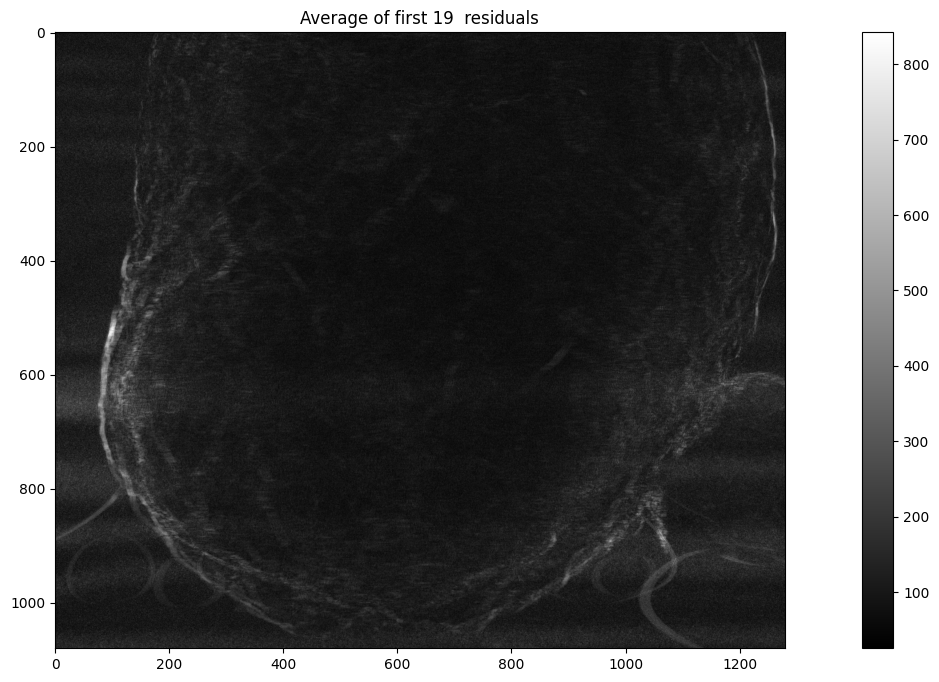

In [75]:
abs_avg = torch.zeros_like(residuals[0])
for i in range(interval[0], interval[1]):
    abs_avg += (residuals[i] - residuals[i].mean()).abs()
abs_avg /= (interval[1] - interval[0])
plt.figure(figsize=(20, 8))
plt.imshow(abs_avg[:])
plt.title(f"Average of first {interval[1] - interval[0]}  residuals")
plt.colorbar()
avg / (abs_avg + 1e-10)

tensor[1080, 1280] n=1382400 (5.3Mb) x∈[-1.000, 1.000] μ=-0.022 σ=0.226

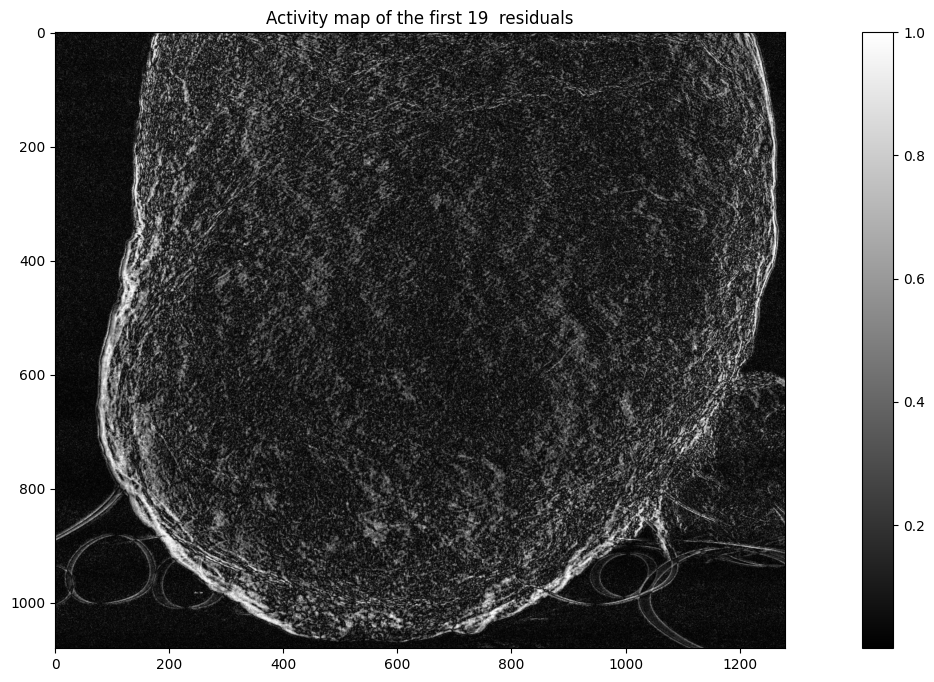

In [76]:
plt.figure(figsize=(20, 8))
activity_map = (avg / (abs_avg + 1e-10)).abs()
plt.imshow(activity_map)
plt.title(f"Activity map of the first {interval[1] - interval[0]}  residuals")
plt.colorbar()
avg / (abs_avg + 1e-10)